# House Price Prediction using Machine Learning in Python

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv("House_Price_Prediction.csv")
dataset.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [4]:
dataset.tail()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN
2918,2918,60,RL,9627,Inside,1Fam,5,1993,1994,HdBoard,0.0,996.0,NaN


In [5]:
dataset.shape

(2919, 13)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [7]:
dataset.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

## Data Preprocessing

In [11]:
object_col = dataset.select_dtypes(include=['object']).columns
print("Categorical variables:", len(object_col))

int_ = dataset.select_dtypes(include=['int64']).columns
print("Integer variables:", len(int_))

fl_cols = dataset.select_dtypes(include=['float64']).columns
print("Float variables:", len(fl_cols))

Categorical variables: 4
Integer variables: 6
Float variables: 3


Heatmap saved as correlation_heatmap.png


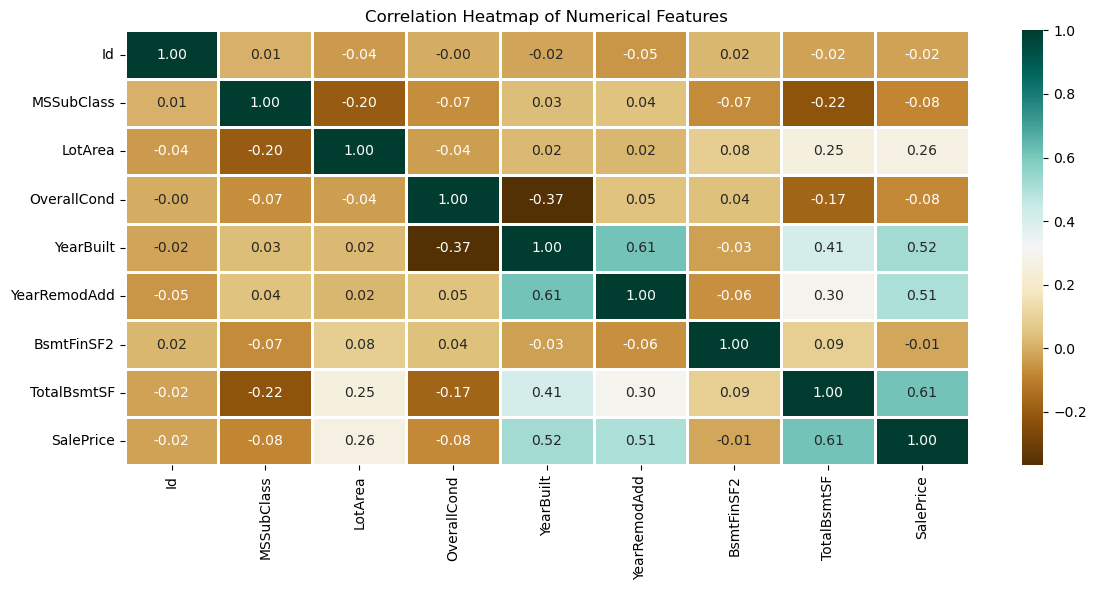

In [12]:
numerical_dataset = dataset.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(), cmap='BrBG', fmt='.2f', linewidths=2, annot=True)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
print("Heatmap saved as correlation_heatmap.png")

<Axes: title={'center': 'No. Unique values of categorical features'}, xlabel='None'>

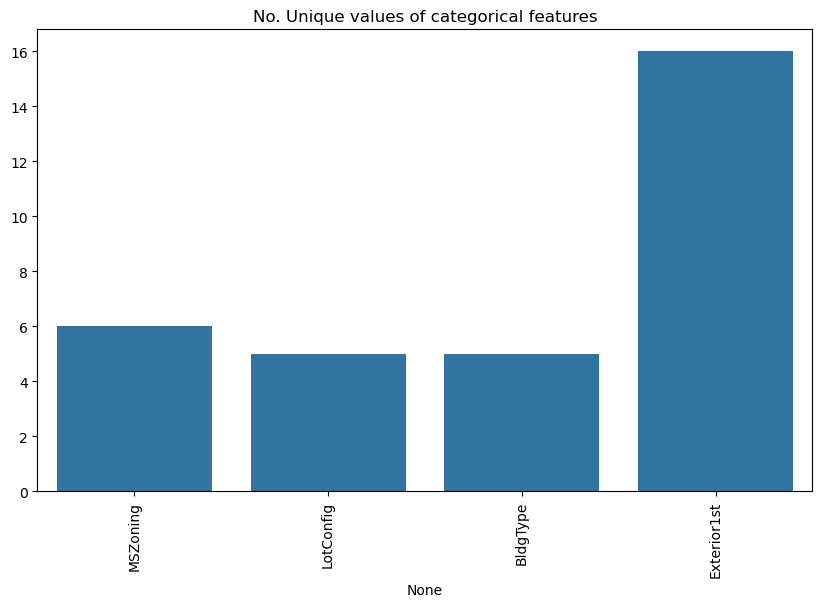

In [15]:
unique_values = []
for col in object_col:
    unique_values.append(dataset[col].unique().size)

plt.figure(figsize=(10, 6))
plt.title('No. Unique values of categorical features')
plt.xticks(rotation=90)
sns.barplot(x=object_col, y=unique_values)

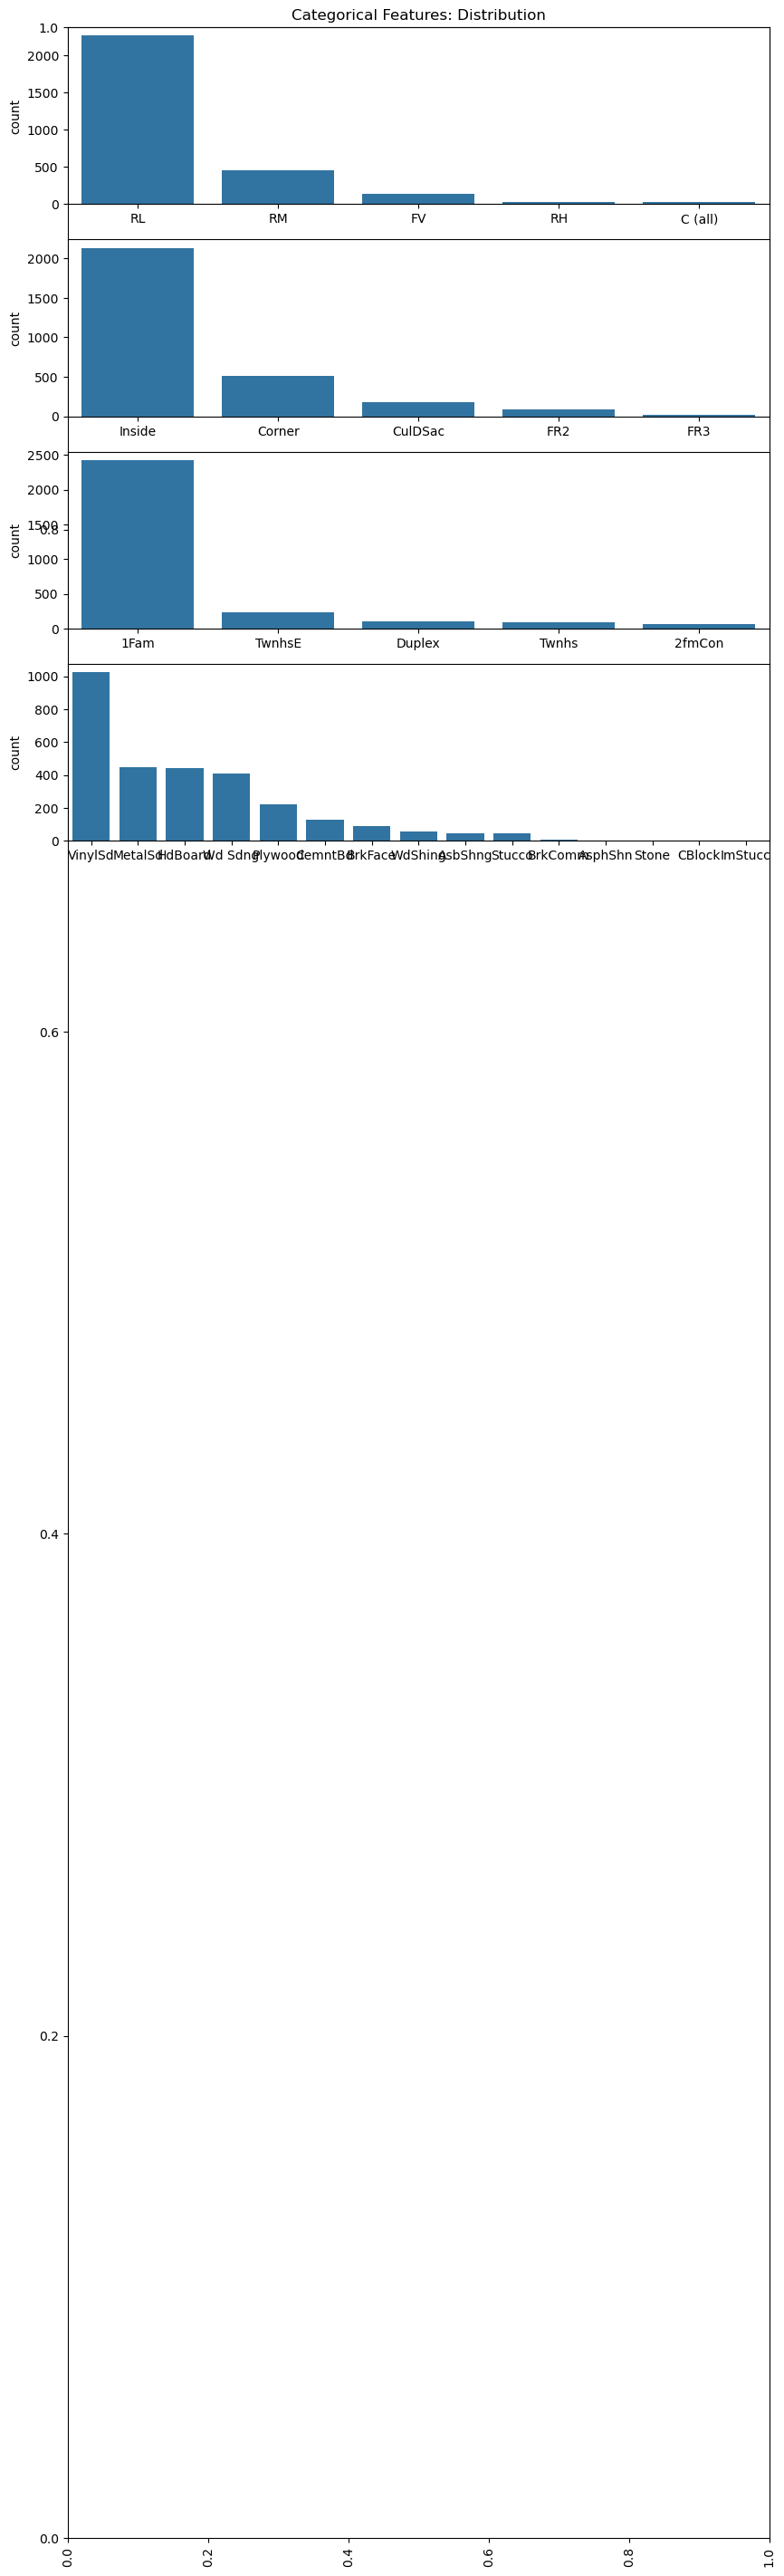

In [22]:
plt.figure(figsize=(10, 36))
plt.title('Categorical Features: Distribution')
plt.xticks(rotation=90)
index = 1

for col in object_col:
    y= dataset[col].value_counts()
    plt.subplot(12, 1, index)
    sns.barplot(x=list(y.index), y=y)
    index +=1

## Data Cleaning

In [23]:
dataset.drop(['Id'], axis=1, inplace=True)

##### Replacing SalePrice empty values with their mean values to make the data distribution symmetric.

In [24]:
dataset['SalePrice'] = dataset['SalePrice'].fillna(dataset['SalePrice'].mean())

In [25]:
new_dataset = dataset.dropna()

In [26]:
new_dataset.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

##### One hot Encoding is the best way to convert categorical data into binary vectors. This maps the values to integer values. By using OneHotEncoder, we can easily convert object data into int. So for that firstly we have to collect all the features which have the object datatype. To do so, we will make a loop.

In [27]:
from sklearn.preprocessing import OneHotEncoder

s= (new_dataset.dtypes =='object')
object_col = list(s[s].index)
print("Categorical variables:")
print(object_col)
print('No.of.categorical features:', len(object_col))

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No.of.categorical features: 4


In [31]:
oh_encoder = OneHotEncoder(sparse_output =False, handle_unknown='ignore')
oh_cols = pd.DataFrame(oh_encoder.fit_transform(new_dataset[object_col]))
oh_cols.index = new_dataset.index
oh_cols.columns = oh_encoder.get_feature_names_out()
df_final = new_dataset.drop(object_col, axis=1)
df_final = pd.concat([df_final, oh_cols], axis=1)

## Splitting Dataset into Training and Testing

In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

X=df_final.drop(['SalePrice'], axis=1)
Y=df_final['SalePrice']

X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=0)


## Model Training and Accuracy

### 1. SVM - Support vector Machine
##### Support vector Machine is a supervised machine learning algorithm primarily used for classification tasks though it can also be used for regression. It works by finding the hyperplane that best divides a dataset into classes. The goal is to maximize the margin between the data points and the hyperplane.

In [33]:
from  sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error

model_SVR = svm.SVR()
model_SVR.fit(X_train, Y_train)
Y_pred = model_SVR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.1870512931870423


### 2. Random Forest Regression
##### Random Forest is an ensemble learning algorithm used for both classification and regression tasks. It constructs multiple decision trees during training where each tree in the forest is built on a random subset of the data and features, ensuring diversity in the model. The final output is determined by averaging the outputs of individual trees (for regression) or by majority voting (for classification).

In [34]:
from sklearn.ensemble import RandomForestRegressor

model_RFR = RandomForestRegressor(n_estimators =10)
model_RFR.fit(X_train, Y_train)
Y_pred = model_RFR.predict(X_valid)
mean_absolute_percentage_error(Y_valid, Y_pred)

0.18794733420725288

### 3. Linear Regression
##### Linear Regression is a statistical method used for modeling the relationship between a dependent variable and one or more independent variables. The goal is to find the line that best fits the data. This is done by minimizing the sum of the squared differences between the observed and predicted values. Linear regression assumes that the relationship between variables is linear.

In [35]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred = model_LR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.18741683841600051


##### Clearly SVM model is giving better accuracy as the mean absolute error is the least among all the other regressor models i.e. 0.18 approx. To get much better results ensemble learning techniques like Bagging and Boosting can also be used.